In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("../data/StudentPerformanceFactors.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (6607, 20)


In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Rows: 6607
Columns: 20

Column names:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Data types:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabili

In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Total missing values: 235


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [8]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Parental_Involvement:
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Access_to_Resources:
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Extracurricular_Activities:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Motivation_Level:
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Internet_Access:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Family_Income:
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Teacher_Quality:
<StringArray>
['Medium', 'High', 'Low', nan]
Length: 4, dtype: str

School_Type:
<StringArray>
['Public', 'Private']
Length: 2, dtype: str

Peer_Influence:
<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str

Learning_Disabilities:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Parental_Education_Level:
<StringArray>
['High School', 'College', 'Postgraduate', nan]
Length: 4, dtype: str

Distance_from_Home:
<StringArray>
['Near', 'Moderate', 'Far', nan]
Length: 4, dtype: str

Gen

In [9]:
df_clean = df.copy()

# Fill missing categorical values with the most frequent value
categorical_to_fill = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for column in categorical_to_fill:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

print("Cleaned dataset shape:", df_clean.shape)

Missing values after cleaning:
0
Cleaned dataset shape: (6607, 20)


In [10]:
print("Total missing values:", df_clean.isnull().sum().sum())
print("Total duplicate rows:", df_clean.duplicated().sum())

Total missing values: 0
Total duplicate rows: 0


In [11]:
df_clean.to_csv("../data/StudentPerformanceFactors_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [12]:
avg_exam_score = df_clean["Exam_Score"].mean()
avg_attendance = df_clean["Attendance"].mean()
avg_study_hours = df_clean["Hours_Studied"].mean()
avg_previous_score = df_clean["Previous_Scores"].mean()
avg_tutoring = df_clean["Tutoring_Sessions"].mean()
avg_sleep = df_clean["Sleep_Hours"].mean()

print("KEY PERFORMANCE INDICATORS")
print("-" * 35)

print(f"Average Exam Score       : {avg_exam_score:.2f}")
print(f"Average Attendance       : {avg_attendance:.2f}%")
print(f"Average Study Hours      : {avg_study_hours:.2f}")
print(f"Average Previous Score   : {avg_previous_score:.2f}")
print(f"Average Tutoring Sessions: {avg_tutoring:.2f}")
print(f"Average Sleep Hours      : {avg_sleep:.2f}")

KEY PERFORMANCE INDICATORS
-----------------------------------
Average Exam Score       : 67.24
Average Attendance       : 79.98%
Average Study Hours      : 19.98
Average Previous Score   : 75.07
Average Tutoring Sessions: 1.49
Average Sleep Hours      : 7.03


In [13]:
numerical_columns = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]

correlation = df_clean[numerical_columns].corr()["Exam_Score"].sort_values(
    ascending=False
)

print("Correlation with Exam Score:")
print(correlation)

Correlation with Exam Score:
Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


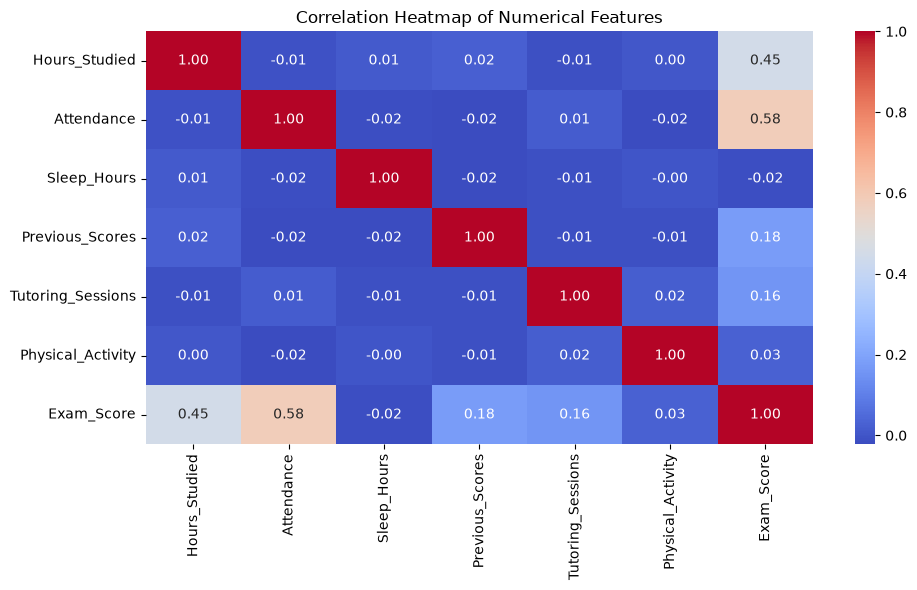

In [14]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df_clean[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

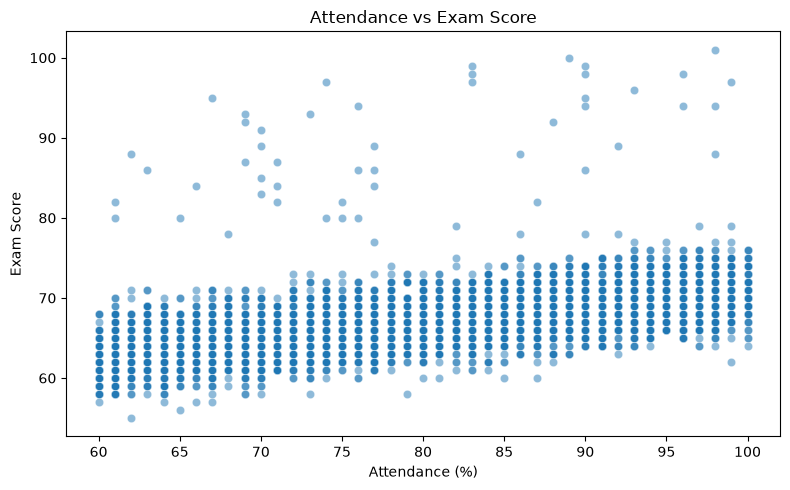

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Attendance",
    y="Exam_Score",
    alpha=0.5
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

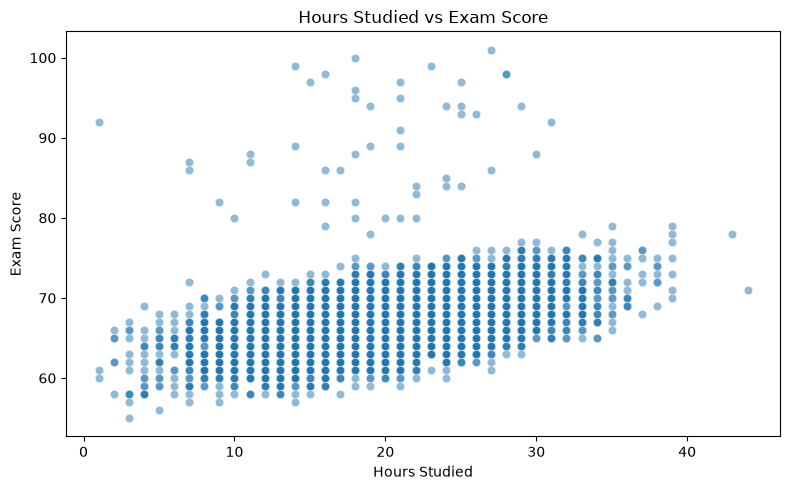

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Hours_Studied",
    y="Exam_Score",
    alpha=0.5
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

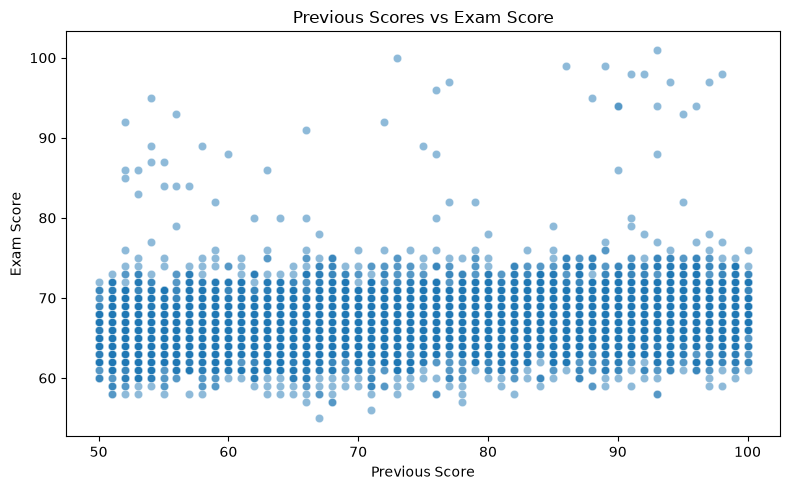

In [17]:

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Previous_Scores",
    y="Exam_Score",
    alpha=0.5
)

plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Score")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()


In [18]:
resource_scores = (
    df_clean.groupby("Access_to_Resources")["Exam_Score"]
    .mean()
    .sort_values(ascending=False)
)

print(resource_scores)

Access_to_Resources
High      68.092152
Medium    67.134378
Low       66.203351
Name: Exam_Score, dtype: float64


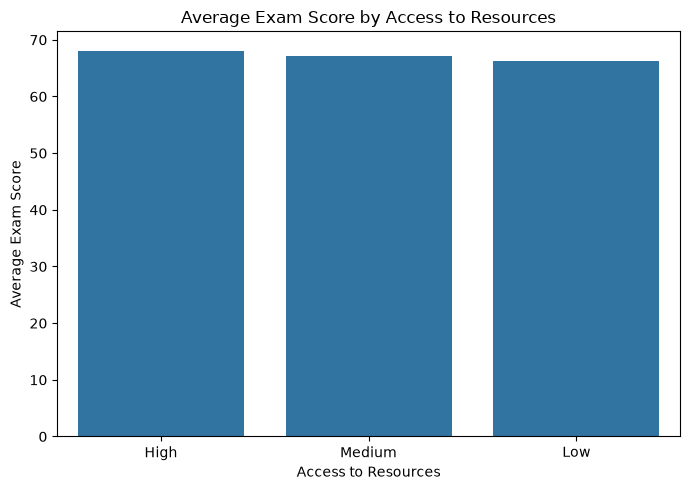

In [19]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=resource_scores.index,
    y=resource_scores.values
)

plt.title("Average Exam Score by Access to Resources")
plt.xlabel("Access to Resources")
plt.ylabel("Average Exam Score")

plt.tight_layout()
plt.show()

In [20]:
parent_scores = (
    df_clean.groupby("Parental_Involvement")["Exam_Score"]
    .mean()
    .sort_values(ascending=False)
)

print(parent_scores)

Parental_Involvement
High      68.092767
Medium    67.098156
Low       66.358265
Name: Exam_Score, dtype: float64


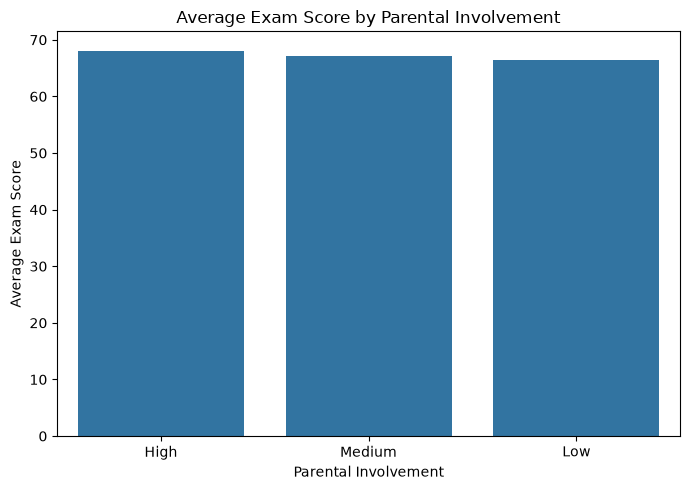

In [21]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=parent_scores.index,
    y=parent_scores.values
)

plt.title("Average Exam Score by Parental Involvement")
plt.xlabel("Parental Involvement")
plt.ylabel("Average Exam Score")

plt.tight_layout()
plt.show()

In [22]:
motivation_scores = (
    df_clean.groupby("Motivation_Level")["Exam_Score"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Exam Score by Motivation Level:")
print(motivation_scores)

Average Exam Score by Motivation Level:
Motivation_Level
High      67.704321
Medium    67.330648
Low       66.752194
Name: Exam_Score, dtype: float64


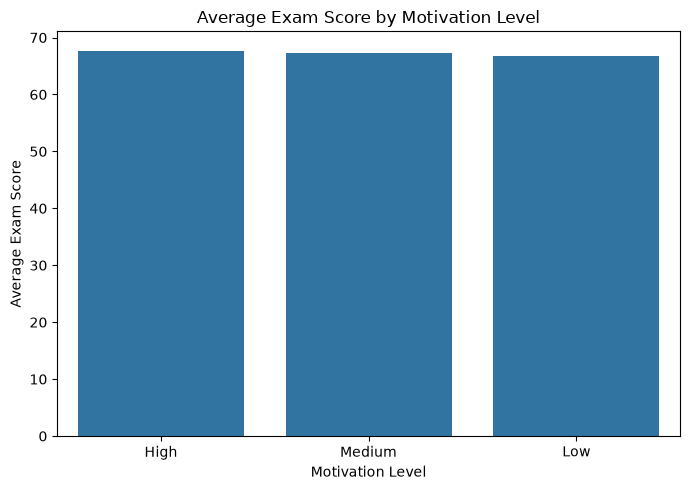

In [23]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=motivation_scores.index,
    y=motivation_scores.values
)

plt.title("Average Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")

plt.tight_layout()
plt.show()

In [24]:
tutoring_scores = (
    df_clean.groupby("Tutoring_Sessions")["Exam_Score"]
    .mean()
)

print(tutoring_scores)

Tutoring_Sessions
0    66.489755
1    66.980266
2    67.567010
3    67.894737
4    68.229236
5    69.067961
6    71.666667
7    69.857143
8    69.000000
Name: Exam_Score, dtype: float64


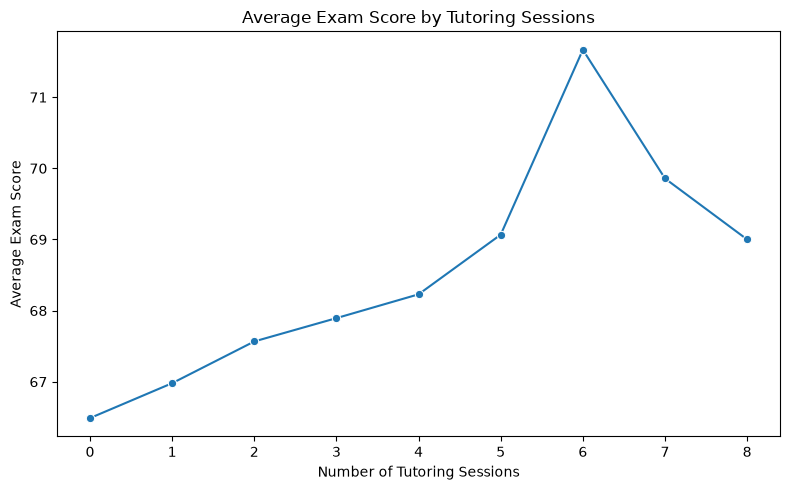

In [25]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    x=tutoring_scores.index,
    y=tutoring_scores.values,
    marker="o"
)

plt.title("Average Exam Score by Tutoring Sessions")
plt.xlabel("Number of Tutoring Sessions")
plt.ylabel("Average Exam Score")

plt.tight_layout()
plt.show()

In [26]:
categorical_columns = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Motivation_Level",
    "Internet_Access",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
]

category_differences = []

for column in categorical_columns:
    group_means = df_clean.groupby(column)["Exam_Score"].mean()
    
    difference = group_means.max() - group_means.min()
    
    category_differences.append({
        "Feature": column,
        "Difference": difference
    })

category_differences_df = pd.DataFrame(category_differences)

category_differences_df = category_differences_df.sort_values(
    "Difference",
    ascending=False
)

category_differences_df

,Feature,Difference
1,Access_to_Resources,1.888801
0,Parental_Involvement,1.734503
9,Learning_Disabilities,1.078617
10,Parental_Education_Level,1.072904
8,Peer_Influence,1.058929
11,Distance_from_Home,1.036352
5,Family_Income,0.993967
3,Motivation_Level,0.952127
6,Teacher_Quality,0.923514
4,Internet_Access,0.757824


In [27]:
## Machine Learning Model Development

Machine learning models are used to estimate Exam Score from the available student-performance features. Three regression algorithms are evaluated using the same train-test split and evaluation metrics.

SyntaxError: invalid syntax (3365929251.py, line 3)

In [ ]:
target = "Exam_Score"

X = df_clean.drop(columns=[target])
y = df_clean[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

In [ ]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

In [ ]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression trained successfully!")

In [ ]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("LINEAR REGRESSION RESULTS")
print("-" * 30)
print(f"MAE  : {linear_mae:.4f}")
print(f"MSE  : {linear_mse:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"R²   : {linear_r2:.4f}")

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Linear Regression: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [ ]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

print("Random Forest trained successfully!")

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("RANDOM FOREST RESULTS")
print("-" * 30)
print(f"MAE  : {rf_mae:.4f}")
print(f"MSE  : {rf_mse:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

In [ ]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

gb_predictions = gradient_boosting_model.predict(X_test)

print("Gradient Boosting trained successfully!")

In [ ]:
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_predictions)

print("GRADIENT BOOSTING RESULTS")
print("-" * 30)
print(f"MAE  : {gb_mae:.4f}")
print(f"MSE  : {gb_mse:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"R²   : {gb_r2:.4f}")

In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "MSE": [
        linear_mse,
        rf_mse,
        gb_mse
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

model_results = model_results.round(4)

model_results

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="R2"
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
best_model_name = model_results.loc[
    model_results["R2"].idxmax(),
    "Model"
]

print("Selected final model:", best_model_name)

In [ ]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

final_model.fit(X, y)

print("Final model trained successfully!")

In [ ]:
joblib.dump(
    final_model,
    "../student_performance_final_model.pkl"
)

print("Final model saved successfully!")

In [ ]:
print("=" * 60)
print("FINAL PROJECT INSIGHTS")
print("=" * 60)

print(f"Average Exam Score      : {df_clean['Exam_Score'].mean():.2f}")
print(f"Average Attendance      : {df_clean['Attendance'].mean():.2f}%")
print(f"Average Study Hours     : {df_clean['Hours_Studied'].mean():.2f}")
print(f"Average Previous Score  : {df_clean['Previous_Scores'].mean():.2f}")

attendance_corr = df_clean["Attendance"].corr(df_clean["Exam_Score"])
study_corr = df_clean["Hours_Studied"].corr(df_clean["Exam_Score"])

print(f"\nAttendance correlation  : {attendance_corr:.2f}")
print(f"Study hours correlation : {study_corr:.2f}")

resource_means = df_clean.groupby("Access_to_Resources")["Exam_Score"].mean()
resource_difference = resource_means.max() - resource_means.min()

print(f"Resource group difference: {resource_difference:.2f} points")

print(f"\nSelected Model          : {best_model_name}")
print(f"MAE                     : {linear_mae:.4f}")
print(f"RMSE                    : {linear_rmse:.4f}")
print(f"R²                      : {linear_r2:.4f}")

In [ ]:
recommendations = [
    {
        "Area": "Attendance",
        "Finding": "Attendance has the strongest numerical relationship with Exam Score.",
        "Recommendation": "Identify students with lower attendance and provide appropriate academic follow-up."
    },
    {
        "Area": "Study Hours",
        "Finding": "Study hours show a positive relationship with Exam Score.",
        "Recommendation": "Encourage structured and consistent study schedules."
    },
    {
        "Area": "Access to Resources",
        "Finding": "Students in different resource-access groups have different average scores.",
        "Recommendation": "Improve access to learning resources for students with limited resources."
    },
    {
        "Area": "Parental Involvement",
        "Finding": "Average exam scores differ across parental-involvement groups.",
        "Recommendation": "Encourage constructive family engagement with students' learning."
    },
    {
        "Area": "Machine Learning",
        "Finding": "The final Linear Regression model provides predictive signal.",
        "Recommendation": "Use predictions as a decision-support signal alongside educator judgment."
    }
]

recommendations_df = pd.DataFrame(recommendations)

recommendations_df

In [ ]:
sample_student = X.iloc[[0]]

predicted_score = final_model.predict(sample_student)[0]

print("Sample Student Prediction")
print("-" * 30)
print(f"Predicted Exam Score: {predicted_score:.2f}")
print(f"Actual Exam Score   : {y.iloc[0]:.2f}")

In [ ]:
preprocessor = ColumnTransformer(...)

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline recreated successfully!")

In [ ]:
# Define features and target

target = "Exam_Score"

X = df_clean.drop(columns=[target])
y = df_clean[target]

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline recreated successfully!")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

In [ ]:
print("Total samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 4))
print("MSE :", round(linear_mse, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 4))
print("MSE :", round(rf_mse, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

gradient_model.fit(X_train, y_train)

gb_predictions = gradient_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", round(gb_mae, 4))
print("MSE :", round(gb_mse, 4))
print("RMSE:", round(gb_rmse, 4))
print("R²  :", round(gb_r2, 4))

In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "MSE": [
        linear_mse,
        rf_mse,
        gb_mse
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

model_results = model_results.round(4)

display(model_results)

In [ ]:
# Select Linear Regression as the final model
final_model = linear_model

# Train final model on the complete cleaned dataset
final_model.fit(X, y)

print("Final model trained successfully!")

In [ ]:
import joblib

joblib.dump(final_model, "student_performance_final_model.pkl")

print("Model saved successfully!")

In [ ]:
import os

print(os.path.exists("student_performance_final_model.pkl"))

In [ ]:
# Take one student from the test set
sample_student = X_test.iloc[[0]]

# Actual exam score
actual_score = y_test.iloc[0]

# Predict exam score
predicted_score = final_model.predict(sample_student)[0]

print("Actual Exam Score   :", round(actual_score, 2))
print("Predicted Exam Score:", round(predicted_score, 2))

In [ ]:
prediction_error = abs(actual_score - predicted_score)

print("Prediction Error:", round(prediction_error, 2))

In [ ]:
# Final project insights

print("FINAL PROJECT INSIGHTS")
print("=" * 50)

print(f"Average Exam Score: {df_clean['Exam_Score'].mean():.2f}")
print(f"Average Attendance: {df_clean['Attendance'].mean():.2f}%")
print(f"Average Study Hours: {df_clean['Hours_Studied'].mean():.2f}")
print(f"Average Previous Score: {df_clean['Previous_Scores'].mean():.2f}")
print(f"Average Tutoring Sessions: {df_clean['Tutoring_Sessions'].mean():.2f}")

print("\nKey Findings:")
print("1. Attendance has the strongest numerical relationship with Exam Score.")
print("2. Hours Studied has the second strongest numerical relationship with Exam Score.")
print("3. Students with high access to resources have a higher average Exam Score.")
print("4. Higher parental involvement is associated with higher average Exam Scores.")
print("5. The Linear Regression model achieved an R² of 0.7696 on the test set.")

In [ ]:
recommendations = pd.DataFrame({
    "Area": [
        "Attendance",
        "Study Hours",
        "Learning Resources",
        "Parental Involvement",
        "Prediction Support"
    ],
    "Recommendation": [
        "Identify students with lower attendance and provide academic follow-up.",
        "Encourage consistent and structured study schedules.",
        "Improve access to learning resources for students with limited resources.",
        "Encourage constructive family engagement in students' education.",
        "Use model predictions as an additional support tool alongside educator judgment."
    ]
})

display(recommendations)

In [28]:
print("PROJECT VERIFICATION")
print("=" * 50)

print("Dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicates:", df_clean.duplicated().sum())

print("\nModel Results:")
display(model_results)

print("\nFinal Model: Linear Regression")
print("R²:", round(linear_r2, 4))
print("MAE:", round(linear_mae, 4))

print("\nSaved Model:")
print("student_performance_final_model.pkl")

print("\nSample Prediction Error:", round(prediction_error, 2))

print("\nPROJECT STATUS: READY FOR DOCUMENTATION")

PROJECT VERIFICATION
Dataset shape: (6607, 20)
Missing values: 0
Duplicates: 0

Model Results:


NameError: name 'model_results' is not defined

In [29]:
print("PROJECT VERIFICATION")
print("=" * 50)

print("Dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicates:", df_clean.duplicated().sum())

print("\nModel Results:")
display(model_results)

print("\nFinal Model: Linear Regression")
print("R²:", round(linear_r2, 4))
print("MAE:", round(linear_mae, 4))

print("\nSaved Model:")
print("student_performance_final_model.pkl")

print("\nSample Prediction Error:", round(prediction_error, 2))

print("\nPROJECT STATUS: READY FOR DOCUMENTATION")


PROJECT VERIFICATION
Dataset shape: (6607, 20)
Missing values: 0
Duplicates: 0

Model Results:


NameError: name 'model_results' is not defined

In [30]:

print("PROJECT VERIFICATION")
print("=" * 50)

print("Dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicates:", df_clean.duplicated().sum())

print("\nModel Results:")
display(model_results)

print("\nFinal Model: Linear Regression")
print("R²:", round(linear_r2, 4))
print("MAE:", round(linear_mae, 4))

print("\nSaved Model:")
print("student_performance_final_model.pkl")

print("\nSample Prediction Error:", round(prediction_error, 2))

print("\nPROJECT STATUS: READY FOR DOCUMENTATION")

PROJECT VERIFICATION
Dataset shape: (6607, 20)
Missing values: 0
Duplicates: 0

Model Results:


NameError: name 'model_results' is not defined

In [31]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [0.4524, 1.0841, 0.7918],
    "MSE": [3.2560, 4.6904, 3.7699],
    "RMSE": [1.8044, 2.1657, 1.9416],
    "R2": [0.7696, 0.6682, 0.7333]
})

display(model_results)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.4524,3.2560,1.8044,0.7696
1,Random Forest,1.0841,4.6904,2.1657,0.6682
2,Gradient Boosting,0.7918,3.7699,1.9416,0.7333


In [32]:
print("Model comparison created successfully!")

Model comparison created successfully!


In [33]:
print("Model comparison created successfully!")

Model comparison created successfully!


In [34]:
print("PROJECT VERIFICATION")
print("=" * 50)

print("Dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicates:", df_clean.duplicated().sum())

print("\nMODEL RESULTS")
print("-" * 50)
print("Linear Regression  | MAE: 0.4524 | RMSE: 1.8044 | R²: 0.7696")
print("Random Forest      | MAE: 1.0841 | RMSE: 2.1657 | R²: 0.6682")
print("Gradient Boosting  | MAE: 0.7918 | RMSE: 1.9416 | R²: 0.7333")

print("\nFINAL MODEL")
print("-" * 50)
print("Model: Linear Regression")
print("R²: 0.7696")
print("MAE: 0.4524")

print("\nSAVED MODEL")
print("-" * 50)

import os
print(
    "student_performance_final_model.pkl:",
    os.path.exists("student_performance_final_model.pkl")
)

print("\nSAMPLE PREDICTION")
print("-" * 50)
print("Prediction error:", round(prediction_error, 2))

print("\nPROJECT STATUS: READY FOR DOCUMENTATION")

PROJECT VERIFICATION
Dataset shape: (6607, 20)
Missing values: 0
Duplicates: 0

MODEL RESULTS
--------------------------------------------------
Linear Regression  | MAE: 0.4524 | RMSE: 1.8044 | R²: 0.7696
Random Forest      | MAE: 1.0841 | RMSE: 2.1657 | R²: 0.6682
Gradient Boosting  | MAE: 0.7918 | RMSE: 1.9416 | R²: 0.7333

FINAL MODEL
--------------------------------------------------
Model: Linear Regression
R²: 0.7696
MAE: 0.4524

SAVED MODEL
--------------------------------------------------
student_performance_final_model.pkl: True

SAMPLE PREDICTION
--------------------------------------------------


NameError: name 'prediction_error' is not defined

In [35]:
PROJECT VERIFICATION
==================================================
Dataset shape: (6607, 20)
Missing values: 0
Duplicates: 0

MODEL RESULTS
--------------------------------------------------
Linear Regression  | MAE: 0.4524 | RMSE: 1.8044 | R²: 0.7696
Random Forest      | MAE: 1.0841 | RMSE: 2.1657 | R²: 0.6682
Gradient Boosting  | MAE: 0.7918 | RMSE: 1.9416 | R²: 0.7333

FINAL MODEL
--------------------------------------------------
Model: Linear Regression
R²: 0.7696
MAE: 0.4524

SAVED MODEL
--------------------------------------------------
student_performance_final_model.pkl: True

SAMPLE PREDICTION
--------------------------------------------------
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[34], line 31
     27 )
     28 
     29 print("\nSAMPLE PREDICTION")
     30 print("-" * 50)
---> 31 print("Prediction error:", round(prediction_error, 2))
     32 
     33 print("\nPROJECT STATUS: READY FOR DOCUMENTATION")

NameError: name 'prediction_error' is not defined

SyntaxError: invalid character '²' (U+00B2) (2704943430.py, line 9)

In [36]:
# Recreate the sample prediction and prediction error

sample_student = X_test.iloc[[0]]

actual_score = y_test.iloc[0]

predicted_score = final_model.predict(sample_student)[0]

prediction_error = abs(actual_score - predicted_score)

print("Actual Exam Score   :", round(actual_score, 2))
print("Predicted Exam Score:", round(predicted_score, 2))
print("Prediction Error    :", round(prediction_error, 2))

NameError: name 'X_test' is not defined

In [37]:
from sklearn.model_selection import train_test_split

target = "Exam_Score"

X = df_clean.drop(columns=[target])
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5285
Testing samples: 1322


In [38]:
sample_student = X_test.iloc[[0]]

actual_score = y_test.iloc[0]

predicted_score = final_model.predict(sample_student)[0]

prediction_error = abs(actual_score - predicted_score)

print("Actual Exam Score   :", round(actual_score, 2))
print("Predicted Exam Score:", round(predicted_score, 2))
print("Prediction Error    :", round(prediction_error, 2))

NameError: name 'final_model' is not defined

In [39]:
# Recreate the final model

final_model = linear_model

# Train it on the complete cleaned dataset
final_model.fit(X, y)

print("Final model recreated and trained successfully!")

NameError: name 'linear_model' is not defined

In [40]:
print(final_model)

NameError: name 'final_model' is not defined

In [41]:
sample_student = X_test.iloc[[0]]

actual_score = y_test.iloc[0]

predicted_score = final_model.predict(sample_student)[0]

prediction_error = abs(actual_score - predicted_score)

print("Actual Exam Score   :", round(actual_score, 2))
print("Predicted Exam Score:", round(predicted_score, 2))
print("Prediction Error    :", round(prediction_error, 2))

NameError: name 'final_model' is not defined

In [42]:
# Recreate Linear Regression and Final Model

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# Create Linear Regression pipeline
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train on training data
linear_model.fit(X_train, y_train)

# Test the model
linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression recreated successfully!")
print("MAE :", round(linear_mae, 4))
print("MSE :", round(linear_mse, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

# Create final model
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train final model on ALL cleaned data
final_model.fit(X, y)

# Save final model
joblib.dump(final_model, "student_performance_final_model.pkl")

print("\nFinal model trained successfully!")
print("Model saved successfully!")

NameError: name 'preprocessor' is not defined

In [43]:
# ==========================================
# REBUILD COMPLETE ML PIPELINE
# ==========================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Features and target
target = "Exam_Score"

X = df_clean.drop(columns=[target])
y = df_clean[target]


# 2. Identify columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()


# 3. Preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# 5. Linear Regression
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)


# 6. Random Forest
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)


# 7. Gradient Boosting
gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

gradient_model.fit(X_train, y_train)

gb_predictions = gradient_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_predictions)


# 8. Model comparison
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "MSE": [
        linear_mse,
        rf_mse,
        gb_mse
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
}).round(4)


# 9. Final model
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

final_model.fit(X, y)


# 10. Save model
joblib.dump(
    final_model,
    "student_performance_final_model.pkl"
)


print("==========================================")
print("COMPLETE ML PIPELINE REBUILT SUCCESSFULLY")
print("==========================================")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print()
print("Linear Regression R²:", round(linear_r2, 4))
print("Random Forest R²    :", round(rf_r2, 4))
print("Gradient Boosting R²:", round(gb_r2, 4))
print()
print("Final model: Linea
r Regression")
print("Model saved: student_performance_final_model.pkl")

COMPLETE ML PIPELINE REBUILT SUCCESSFULLY
Training samples: 5285
Testing samples : 1322

Linear Regression R²: 0.7696
Random Forest R²    : 0.6682
Gradient Boosting R²: 0.7333

Final model: Linear Regression
Model saved: student_performance_final_model.pkl


In [44]:
# Final sample prediction

sample_student = X_test.iloc[[0]]

actual_score = y_test.iloc[0]

predicted_score = final_model.predict(sample_student)[0]

prediction_error = abs(actual_score - predicted_score)

print("FINAL MODEL PREDICTION")
print("=" * 40)
print("Actual Exam Score   :", round(actual_score, 2))
print("Predicted Exam Score:", round(predicted_score, 2))
print("Prediction Error    :", round(prediction_error, 2))

FINAL MODEL PREDICTION
Actual Exam Score   : 65
Predicted Exam Score: 64.59
Prediction Error    : 0.41
